# 📊 Notebook 3: Variable Visualization

**Topik:** Pie Chart, Bar Chart, Line Graph, Scatter Plot, Heatmap

**Library:** Matplotlib & Seaborn

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi tampilan
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')

# Load dataset EPL
df = pd.read_csv('epl_goalscorer_2021.csv')

print('✅ Setup selesai!')
print(f'Matplotlib: {plt.matplotlib.__version__}')
print(f'Seaborn   : {sns.__version__}')

✅ Setup selesai!
Matplotlib: 3.10.8
Seaborn   : 0.13.2


---
## 1. Pie Chart

**Kegunaan:** Menampilkan proporsi tiap kategori terhadap keseluruhan.

**Best for:** Data kategorikal dengan ≤6 kategori.

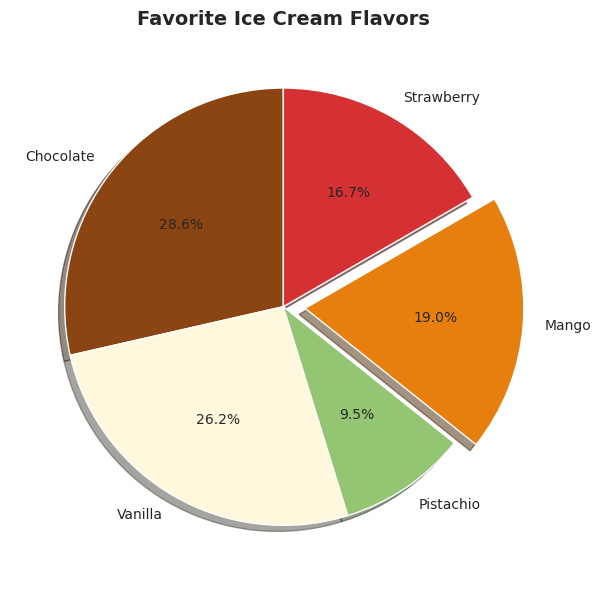

✅ Plot disimpan: plot_pie_icecream.png


In [3]:
# === CONTOH 1: Pie chart voting ice cream (persis dari materi) ===
flavors = ('Chocolate', 'Vanilla', 'Pistachio', 'Mango', 'Strawberry')
votes   = (12, 11, 4, 8, 7)
colors  = ('#8B4513', '#FFF8DC', '#93C572', '#E67F0D', '#D53032')
explode = (0, 0, 0, 0.1, 0)

plt.figure(figsize=(8, 6))
plt.title('Favorite Ice Cream Flavors', fontsize=14, fontweight='bold')
plt.pie(
    votes,
    labels=flavors,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90
)
plt.tight_layout()
plt.savefig('plot_pie_icecream.png', bbox_inches='tight')
plt.show()
print('✅ Plot disimpan: plot_pie_icecream.png')

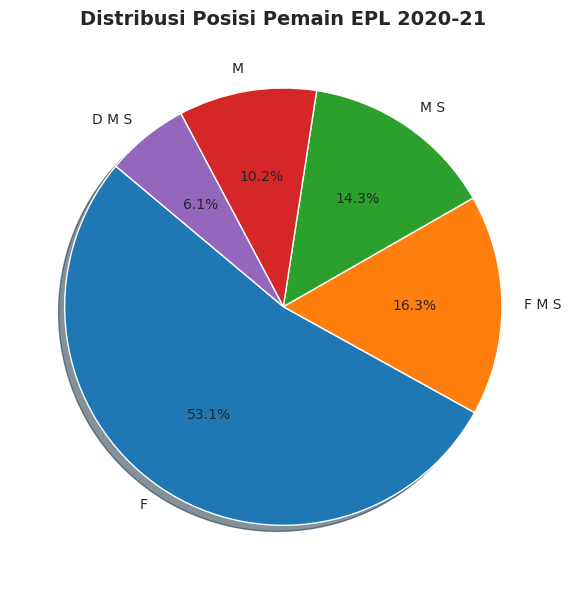

In [4]:
# === CONTOH 2: Pie chart proporsi pemain EPL berdasarkan posisi ===
pos_counts = df['position'].value_counts().head(5)

plt.figure(figsize=(8, 6))
plt.title('Distribusi Posisi Pemain EPL 2020-21', fontsize=14, fontweight='bold')
plt.pie(
    pos_counts.values,
    labels=pos_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True
)
plt.tight_layout()
plt.savefig('plot_pie_position.png', bbox_inches='tight')
plt.show()

---
## 2. Bar Chart

**Kegunaan:** Membandingkan nilai antar kategori.

**Kelebihan vs Pie:** Bisa menampilkan lebih banyak kategori dengan lebih jelas.

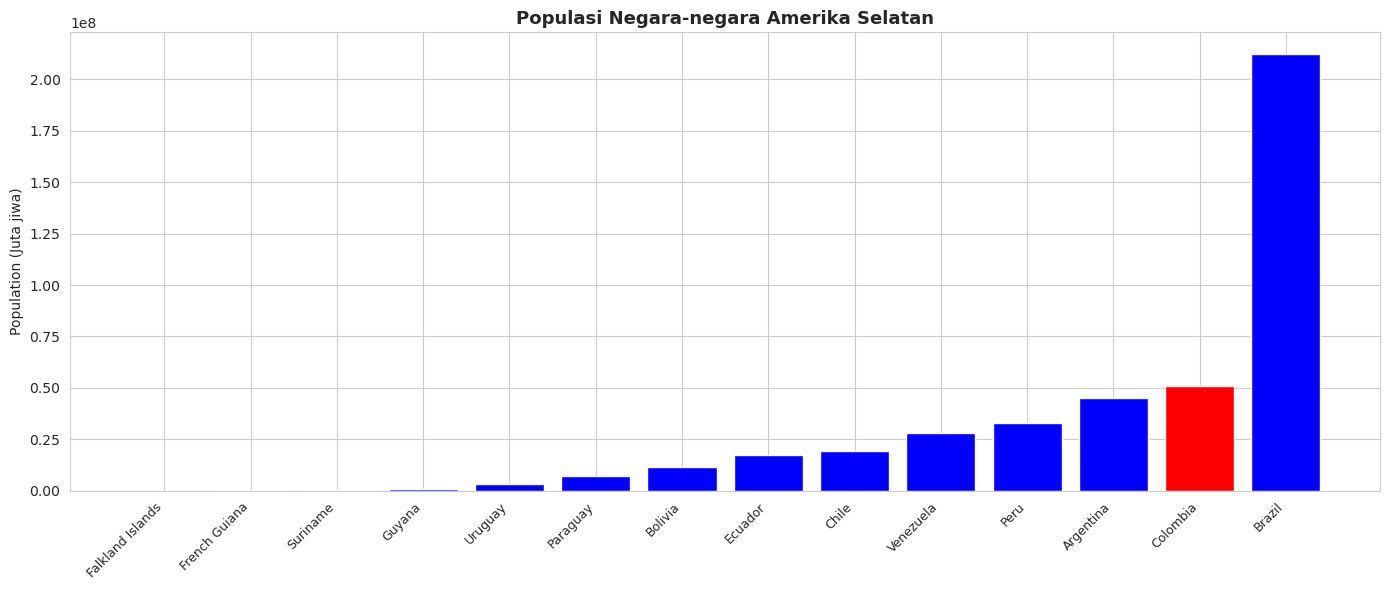

🔴 Warna merah = Colombia (highlighted)


In [6]:
# === CONTOH 1: Bar chart populasi Amerika Selatan (dari materi) ===
countries   = ('Argentina','Bolivia','Brazil','Chile','Colombia','Ecuador',
                'Falkland Islands','French Guiana','Guyana','Paraguay',
                'Peru','Suriname','Uruguay','Venezuela')
populations = (45076704,11626410,212162757,19109629,50819826,17579085,
               3481,287750,785409,7107305,32880332,585169,3470475,28258770)

df_pop = pd.DataFrame({'Country': countries, 'Population': populations})
df_pop.sort_values(by='Population', inplace=True)

x_coords = np.arange(len(df_pop))
colors_bar = ['#0000FF'] * len(df_pop)
# Highlight Colombia
colombia_idx = list(df_pop['Country']).index('Colombia')
colors_bar[colombia_idx] = '#FF0000'

plt.figure(figsize=(14, 6))
plt.bar(x_coords, df_pop['Population'], tick_label=df_pop['Country'], color=colors_bar)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Population (Juta jiwa)')
plt.title('Populasi Negara-negara Amerika Selatan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_bar_population.png', bbox_inches='tight')
plt.show()
print('🔴 Warna merah = Colombia (highlighted)')

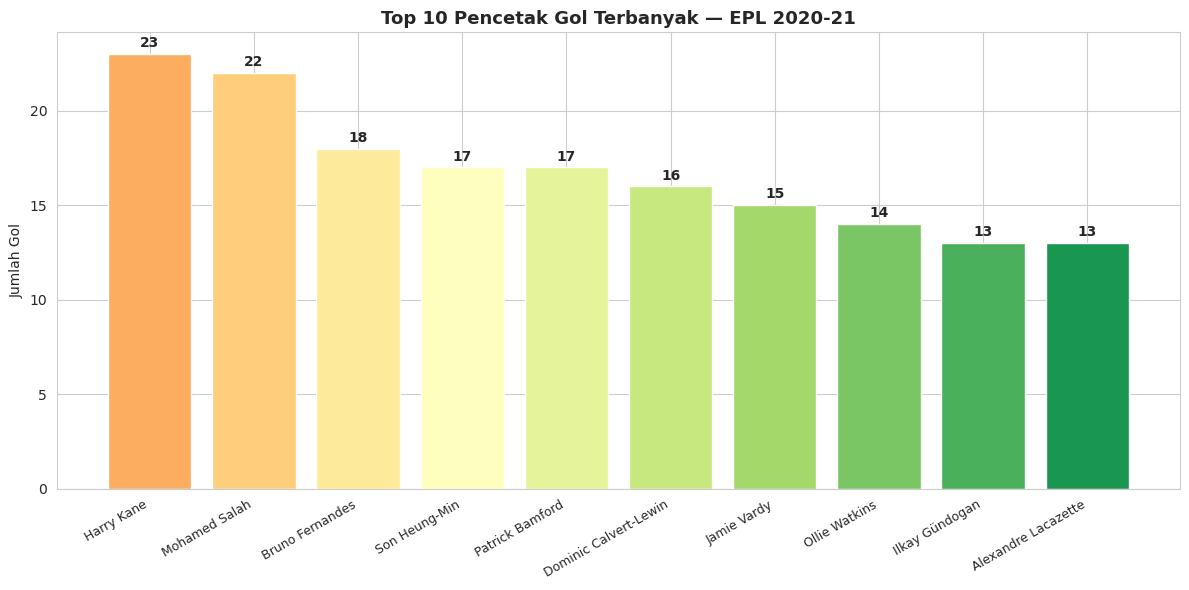

In [7]:
# === CONTOH 2: Bar chart top 10 pencetak gol EPL ===
top10 = df.sort_values('goals', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top10['player_name'], top10['goals'],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 10)))

# Tambah label nilai di atas bar
for bar, val in zip(bars, top10['goals']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=30, ha='right', fontsize=9)
plt.ylabel('Jumlah Gol')
plt.title('Top 10 Pencetak Gol Terbanyak — EPL 2020-21', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_bar_topscorer.png', bbox_inches='tight')
plt.show()

---
## 3. Line Graph

**Kegunaan:** Menampilkan tren data dari waktu ke waktu atau urutan berurutan.

**Best for:** Data kontinu, time-series, perbandingan actual vs prediksi.

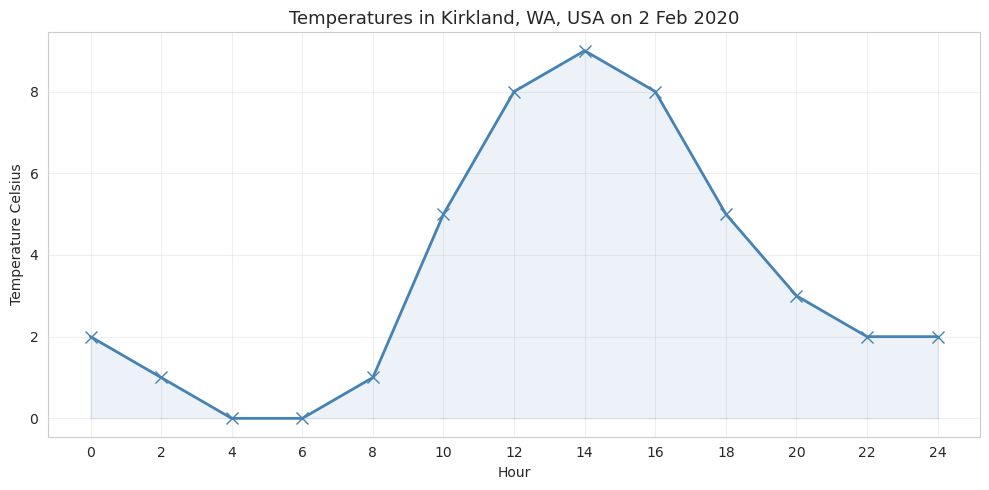

In [8]:
# === CONTOH 1: Line graph suhu per jam (dari materi) ===
temperature_c = [2, 1, 0, 0, 1, 5, 8, 9, 8, 5, 3, 2, 2]
hour          = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]

plt.figure(figsize=(10, 5))
plt.plot(hour, temperature_c, marker='x', linewidth=2, color='steelblue', markersize=8)
plt.fill_between(hour, temperature_c, alpha=0.1, color='steelblue')
plt.title('Temperatures in Kirkland, WA, USA on 2 Feb 2020', fontsize=13)
plt.ylabel('Temperature Celsius')
plt.xlabel('Hour')
plt.xticks(hour)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_line_temperature.png', bbox_inches='tight')
plt.show()

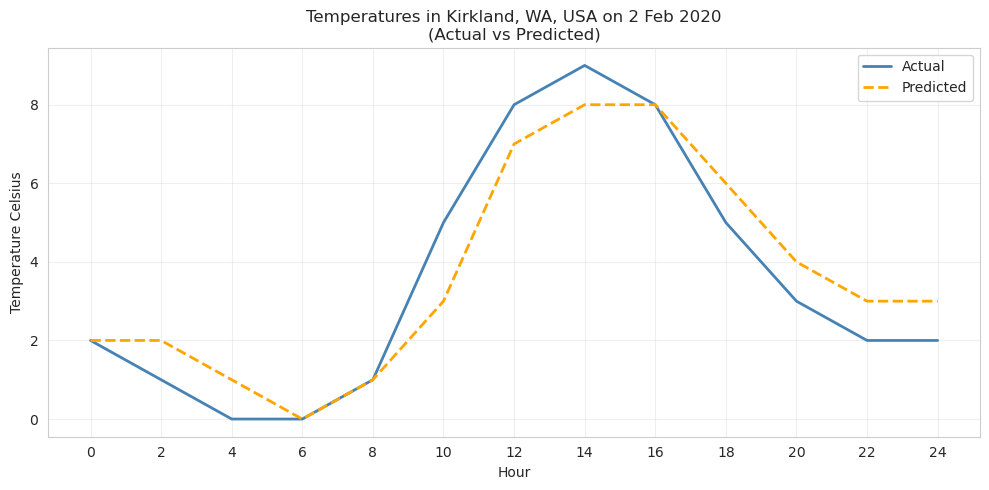

In [9]:
# === CONTOH 2: Line graph Actual vs Predicted (dari materi) ===
temperature_c_actual    = [2, 1, 0, 0, 1,  5, 8, 9, 8, 5, 3, 2, 2]
temperature_c_predicted = [2, 2, 1, 0, 1,  3, 7, 8, 8, 6, 4, 3, 3]
hour = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]

plt.figure(figsize=(10, 5))
plt.plot(hour, temperature_c_actual,    label='Actual',    linewidth=2, color='steelblue')
plt.plot(hour, temperature_c_predicted, label='Predicted', linestyle='--', linewidth=2, color='orange')
plt.title('Temperatures in Kirkland, WA, USA on 2 Feb 2020\n(Actual vs Predicted)', fontsize=12)
plt.ylabel('Temperature Celsius')
plt.xlabel('Hour')
plt.legend()
plt.xticks(hour)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_line_actual_vs_pred.png', bbox_inches='tight')
plt.show()

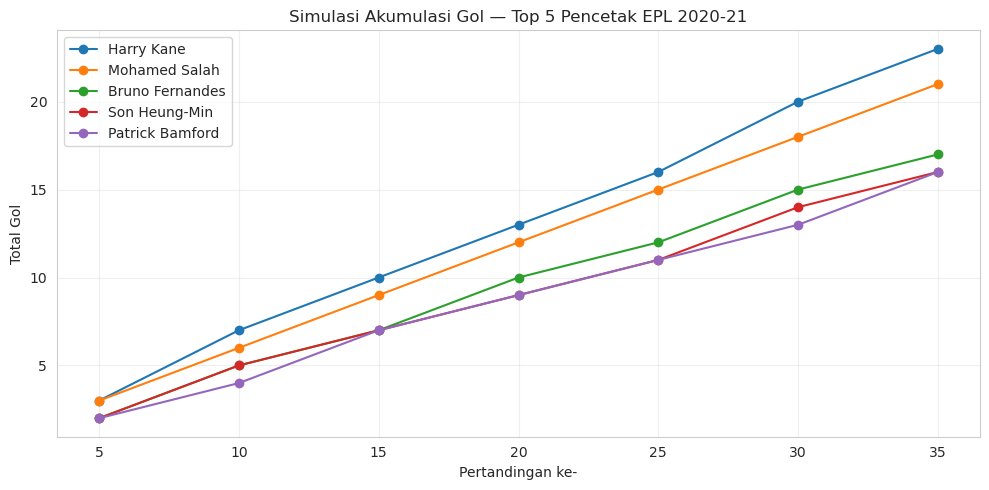

In [11]:
# === CONTOH 3 (Bonus): Tren gol pemain top EPL per rentang pertandingan ===
top5 = df.sort_values('goals', ascending=False).head(5)
match_intervals = np.arange(5, 40, 5)

plt.figure(figsize=(10, 5))
for _, row in top5.iterrows():
    # Simulasi akumulasi gol per interval (proporsi)
    simulated = np.round((match_intervals / row['games']) * row['goals'])
    simulated = np.clip(simulated, 0, row['goals'])
    plt.plot(match_intervals, simulated, marker='o', label=row['player_name'])

plt.title('Simulasi Akumulasi Gol — Top 5 Pencetak EPL 2020-21', fontsize=12)
plt.xlabel('Pertandingan ke-')
plt.ylabel('Total Gol')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_line_goaltrend.png', bbox_inches='tight')
plt.show()

---
## 4. Scatter Plot

**Kegunaan:** Memvisualisasikan hubungan antara dua variabel numerik.

**Best for:** Deteksi korelasi, pola, dan outlier.

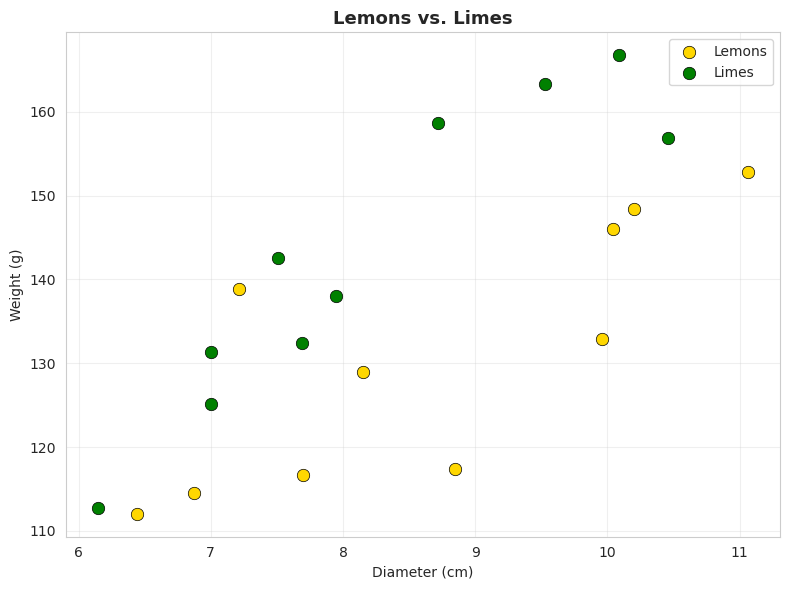

In [12]:
# === CONTOH 1: Scatter plot Lemon vs Lime (dari materi) ===
lemon_diameter = [6.44,6.87,7.7,8.85,8.15,9.96,7.21,10.04,10.2,11.06]
lemon_weight   = [112.05,114.58,116.71,117.4,128.93,132.93,138.92,145.98,148.44,152.81]
lime_diameter  = [6.15,7.0,7.0,7.69,7.95,7.51,10.46,8.72,9.53,10.09]
lime_weight    = [112.76,125.16,131.36,132.41,138.08,142.55,156.86,158.67,163.28,166.74]

plt.figure(figsize=(8, 6))
plt.scatter(lemon_diameter, lemon_weight, color='gold',  s=80, label='Lemons', edgecolors='black', linewidth=0.5)
plt.scatter(lime_diameter,  lime_weight,  color='green', s=80, label='Limes',  edgecolors='black', linewidth=0.5)
plt.title('Lemons vs. Limes', fontsize=13, fontweight='bold')
plt.xlabel('Diameter (cm)')
plt.ylabel('Weight (g)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_scatter_lemon_lime.png', bbox_inches='tight')
plt.show()

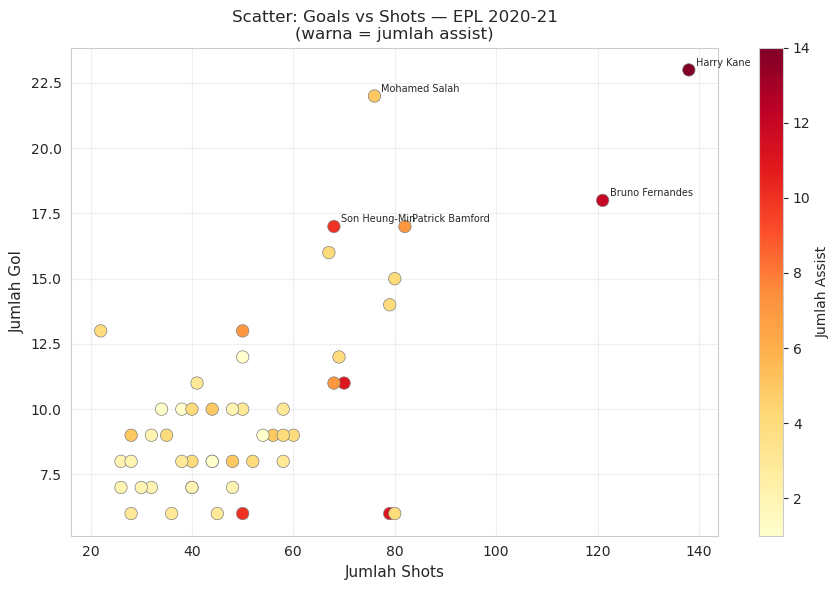

Korelasi Goals vs Shots: 0.6855


In [13]:
# === CONTOH 2: Scatter plot Goals vs Shots (EPL) ===
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['shots'], df['goals'],
    c=df['assists'], cmap='YlOrRd',
    s=80, edgecolors='gray', linewidth=0.5
)
plt.colorbar(scatter, label='Jumlah Assist')

# Annotate top scorers
for _, row in df.nlargest(5, 'goals').iterrows():
    plt.annotate(row['player_name'], (row['shots'], row['goals']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)

plt.xlabel('Jumlah Shots', fontsize=11)
plt.ylabel('Jumlah Gol', fontsize=11)
plt.title('Scatter: Goals vs Shots — EPL 2020-21\n(warna = jumlah assist)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_scatter_goals_shots.png', bbox_inches='tight')
plt.show()

# Korelasi goals dan shots
corr = df['goals'].corr(df['shots'])
print(f'Korelasi Goals vs Shots: {corr:.4f}')

---
## 5. Heatmap

**Kegunaan:** Menampilkan data matriks 2D menggunakan warna untuk merepresentasikan nilai.

**Best for:** Correlation matrix, pivot table, data temporal multi-dimensi.

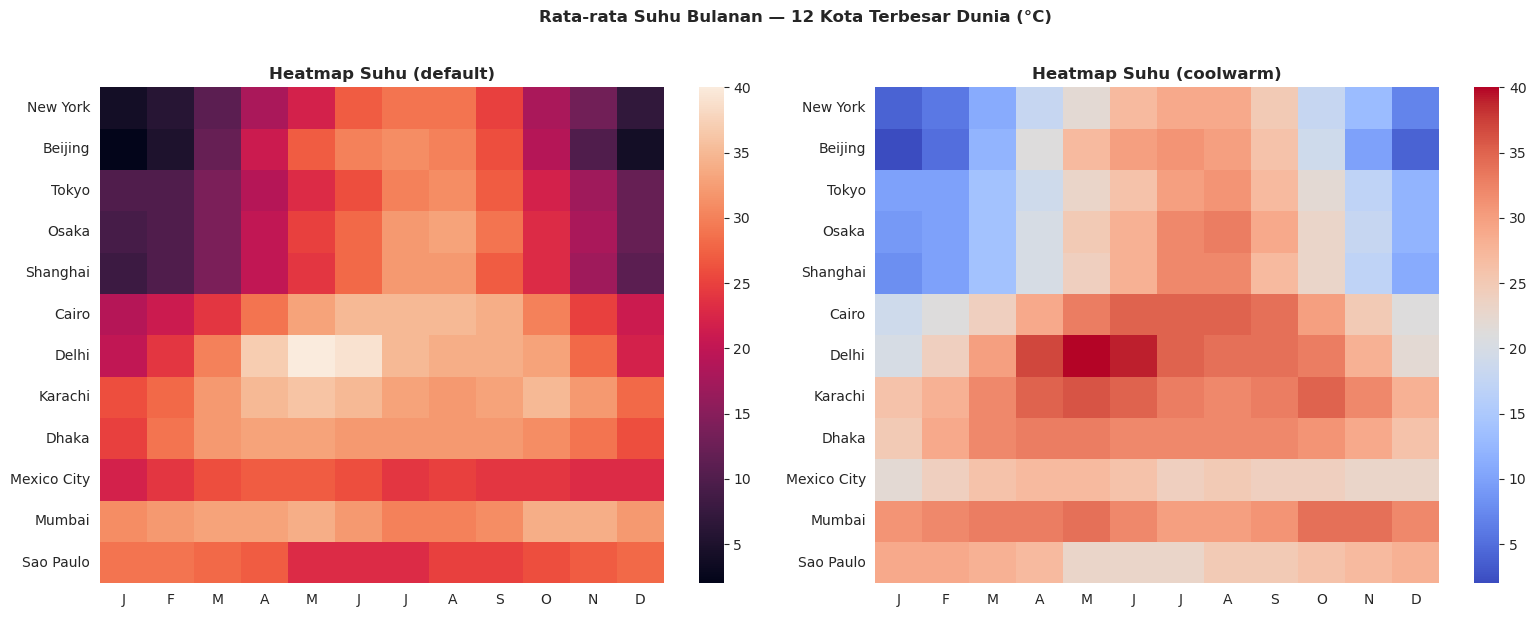

In [14]:
# === CONTOH 1: Heatmap suhu kota-kota besar (dari materi) ===
cities = ['New York','Beijing','Tokyo','Osaka','Shanghai',
          'Cairo','Delhi','Karachi','Dhaka','Mexico City','Mumbai','Sao Paulo']
months = ['J','F','M','A','M','J','J','A','S','O','N','D']
temperatures = [
    [ 4, 6,11,18,22,27,29,29,25,18,13, 7],  # New York
    [ 2, 5,12,21,27,30,31,30,26,19,10, 4],  # Beijing
    [10,10,14,19,23,26,30,31,27,22,17,12],  # Tokyo
    [ 9,10,14,20,25,28,32,33,29,23,18,12],  # Osaka
    [ 8,10,14,20,24,28,32,32,27,23,17,11],  # Shanghai
    [19,21,24,29,33,35,35,35,34,30,25,21],  # Cairo
    [20,24,30,37,40,39,35,34,34,33,28,22],  # Delhi
    [26,28,32,35,36,35,33,32,33,35,32,28],  # Karachi
    [25,29,32,33,33,32,32,32,32,31,29,26],  # Dhaka
    [22,24,26,27,27,26,24,25,24,24,23,23],  # Mexico City
    [31,32,33,33,34,32,30,30,31,34,34,32],  # Mumbai
    [29,29,28,27,23,23,23,25,25,26,27,28],  # Sao Paulo
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Default colormap
sns.heatmap(temperatures, yticklabels=cities, xticklabels=months,
            ax=axes[0], annot=False)
axes[0].set_title('Heatmap Suhu (default)', fontweight='bold')

# Coolwarm colormap (dari materi)
sns.heatmap(temperatures, yticklabels=cities, xticklabels=months,
            cmap='coolwarm', ax=axes[1], annot=False)
axes[1].set_title('Heatmap Suhu (coolwarm)', fontweight='bold')

plt.suptitle('Rata-rata Suhu Bulanan — 12 Kota Terbesar Dunia (°C)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_heatmap_temperature.png', bbox_inches='tight')
plt.show()

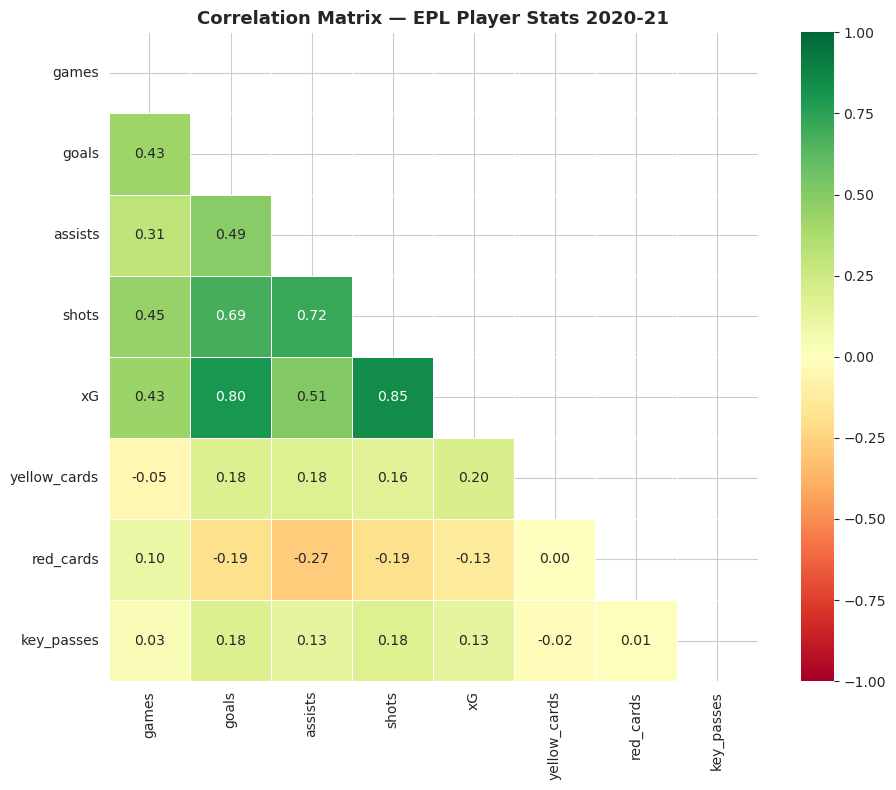


💡 Nilai mendekati 1 = korelasi positif kuat, mendekati -1 = korelasi negatif kuat


In [15]:
# === CONTOH 2: Heatmap Correlation Matrix EPL ===
numeric_cols = df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — EPL Player Stats 2020-21', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_heatmap_correlation.png', bbox_inches='tight')
plt.show()
print('\n💡 Nilai mendekati 1 = korelasi positif kuat, mendekati -1 = korelasi negatif kuat')

---
## 6. Ringkasan Tipe Visualisasi

| Visualisasi | Fungsi | Library | Metode |
|---|---|---|---|
| **Pie Chart** | Proporsi kategori terhadap total | Matplotlib | `plt.pie()` |
| **Bar Chart** | Perbandingan nilai antar kategori | Matplotlib | `plt.bar()` |
| **Line Graph** | Tren data dari waktu ke waktu | Matplotlib | `plt.plot()` |
| **Scatter Plot** | Hubungan 2 variabel numerik | Matplotlib | `plt.scatter()` |
| **Heatmap** | Nilai dalam grid 2D menggunakan warna | Seaborn | `sns.heatmap()` |

> 💡 **Tips:** Seaborn dibangun di atas Matplotlib dan menghasilkan grafik yang lebih menarik secara default.